In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

PROJECT_ROOT = Path().resolve().parent

In [2]:
data = pd.read_csv(PROJECT_ROOT / "data/raw/hvac_synthetic_dataset_v2.csv")
data.head()

,building_type,climate_zone,budget_level,area_sqft,floors,occupancy,operating_hours,building_age,outdoor_temp,humidity,insulation,glass_ratio,heat_gain,cooling_load,tonnage,energy_consumption,installation_cost,efficiency_score,recommendation_confidence,recommended_hvac
0,Residential,Humid,Medium,1021.68,1.0,32.226466,13.0,32.0,31.55,86.31,Good,Medium,1321.86,2509.96,0.12,159.208032,6133.25,99.0,99.95,Split AC
1,Residential,Humid,Medium,1262.42,1.0,28.000000,6.0,12.0,32.12,80.19,Poor,Low,2197.69,2523.35,NaN,53.020000,9218.11,85.0,99.95,Split AC
2,Office,Hot,High,27623.66,2.0,1875.000000,9.0,1.0,45.02,48.57,Excellent,High,84463.45,78023.77,6.50,2135.120000,422464.81,82.0,89.84,Multi-Split
3,Residential,Hot,Low,843.25,1.0,18.000000,8.0,17.0,36.13,27.93,Poor,Low,1708.42,1858.71,0.15,60.490000,6826.34,84.0,100.00,Split AC
4,Office,Hot,Medium,29336.75,3.0,2334.000000,8.0,48.0,NaN,NaN,Average,Medium,195421.83,223473.16,18.62,8425.830000,1917428.81,20.0,47.61,VRF


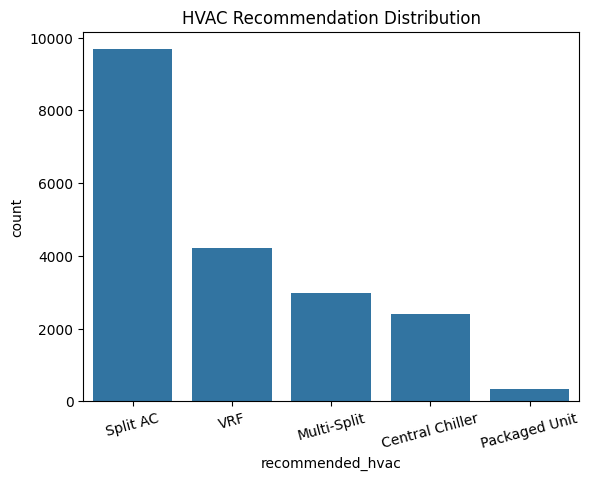

In [4]:
sns.countplot(
    data=data,
    x="recommended_hvac",
    order=data["recommended_hvac"].value_counts().index
)

plt.title("HVAC Recommendation Distribution")
plt.xticks(rotation=15)
plt.show()

In [5]:
print(
    data["recommended_hvac"]
    .value_counts(normalize=True) * 100
)

recommended_hvac
Split AC           49.367347
VRF                21.459184
Multi-Split        15.204082
Central Chiller    12.250000
Packaged Unit       1.719388
Name: proportion, dtype: float64


In [ ]:
numeric_df = data.select_dtypes(include=np.number)

corr = numeric_df.corr()

plt.figure(figsize=(14,10))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Feature Correlation Heatmap")
plt.show()

In [7]:
corr_pairs = corr.unstack()

corr_pairs = corr_pairs.sort_values(
    key=lambda x: abs(x),
    ascending=False
)

# Remove self correlations
corr_pairs = corr_pairs[corr_pairs != 1]

display(corr_pairs.head(20))

heat_gain           tonnage               0.996518
tonnage             heat_gain             0.996518
installation_cost   tonnage               0.990093
tonnage             installation_cost     0.990093
cooling_load        tonnage               0.988355
tonnage             cooling_load          0.988355
heat_gain           installation_cost     0.986095
installation_cost   heat_gain             0.986095
cooling_load        heat_gain             0.984270
heat_gain           cooling_load          0.984270
cooling_load        installation_cost     0.980233
installation_cost   cooling_load          0.980233
energy_consumption  cooling_load          0.970832
cooling_load        energy_consumption    0.970832
energy_consumption  tonnage               0.958782
tonnage             energy_consumption    0.958782
installation_cost   energy_consumption    0.955954
energy_consumption  installation_cost     0.955954
heat_gain           energy_consumption    0.952922
energy_consumption  heat_gain  

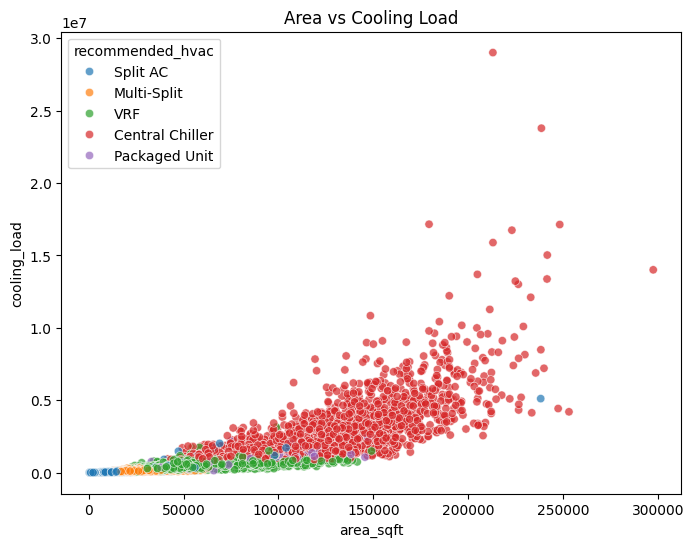

In [8]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=data,
    x="area_sqft",
    y="cooling_load",
    hue="recommended_hvac",
    alpha=0.7
)

plt.title("Area vs Cooling Load")
plt.show()